In [2]:
import pulp
import numpy as np
import matplotlib.pyplot as plt
import math

In [8]:
#Generating synthetic data to formulate and solve
np.random.seed(42)
warehouses=5
plants=50
i=list(range(warehouses))
j=list(range(plants))
warehouse_coord=np.random.randint(0,100,(warehouses,2))
plant_coord=np.random.randint(0,100,(plants,2))
demands=np.random.randint(20,80,size=plants)
d={a : demands[a] for a in j}
total_demand=sum(demands)
base_capacity=int(total_demand*0.4)
capacities=np.random.randint(base_capacity - 100,base_capacity + 200,size=warehouses)
c={b : capacities[b] for b in i}
fixed_costs=[50000+(cap*50)+np.random.randint(-5000, 5000) for cap in capacities] #Cost incurred regardless of sales
f={h : fixed_costs[h] for h in i}
cost={}
for e in i:
    cost[e] = {}
    for g in j:
        # Calculate straight-line distance
        dist = math.sqrt((warehouse_coord[e][0] - plant_coord[g][0])**2 +
                         (warehouse_coord[e][1] - plant_coord[g][1])**2)
        # Store cost rounded to 2 decimals
        cost[e][g] = round(dist * 15, 2) #Assume 15 rs. for each unit distance
print("\n--- Data Generation Complete ---")
print(f"Warehouse Capacities: {c}")
print(f"Warehouse Fixed Costs: {f}")
print("Ready for PuLP implementation.")



--- Data Generation Complete ---
Warehouse Capacities: {0: np.int64(1033), 1: np.int64(841), 2: np.int64(868), 3: np.int64(1005), 4: np.int64(889)}
Warehouse Fixed Costs: {0: np.int64(97513), 1: np.int64(89840), 2: np.int64(95808), 3: np.int64(104005), 4: np.int64(94566)}
Ready for PuLP implementation.


In [10]:
model=pulp.LpProblem("Warehouse_Location_Problem",pulp.LpMinimize)
y = pulp.LpVariable.dicts("Open_Warehouse", i, cat='Binary')
x = pulp.LpVariable.dicts("Shipment", (i, j), lowBound=0, cat='Continuous')
model += (pulp.lpSum([f[a] * y[a] for a in i]) +
    pulp.lpSum([cost[a][b] * x[a][b] for a in i for b in j])
), "Total_Network_Cost"
for b in j:
    model += pulp.lpSum([x[a][b] for a in i]) == d[b], f"Demand_Fulfillment_Plant_{b}"
for a in i:
    model += pulp.lpSum([x[a][b] for b in j]) <= c[a] * y[a], f"Capacity_Logic_Warehouse_{a}"
model.solve()
print(f"Solver Status: {pulp.LpStatus[model.status]}")  #To check if optimal solution is found
print(f"Optimal Total Cost: Rs.{pulp.value(model.objective):,.2f}\n")
print("--- Selected Infrastructure ---")
for a in i:
    if y[a].varValue > 0.5:  # Checking if the binary variable is 1
        print(f"Warehouse {a} is OPENED (Fixed Cost: Rs.{f[a]:,.2f}, Capacity: {c[a]})")

Solver Status: Optimal
Optimal Total Cost: Rs.1,094,784.89

--- Selected Infrastructure ---
Warehouse 1 is OPENED (Fixed Cost: Rs.89,840.00, Capacity: 841)
Warehouse 2 is OPENED (Fixed Cost: Rs.95,808.00, Capacity: 868)
Warehouse 4 is OPENED (Fixed Cost: Rs.94,566.00, Capacity: 889)


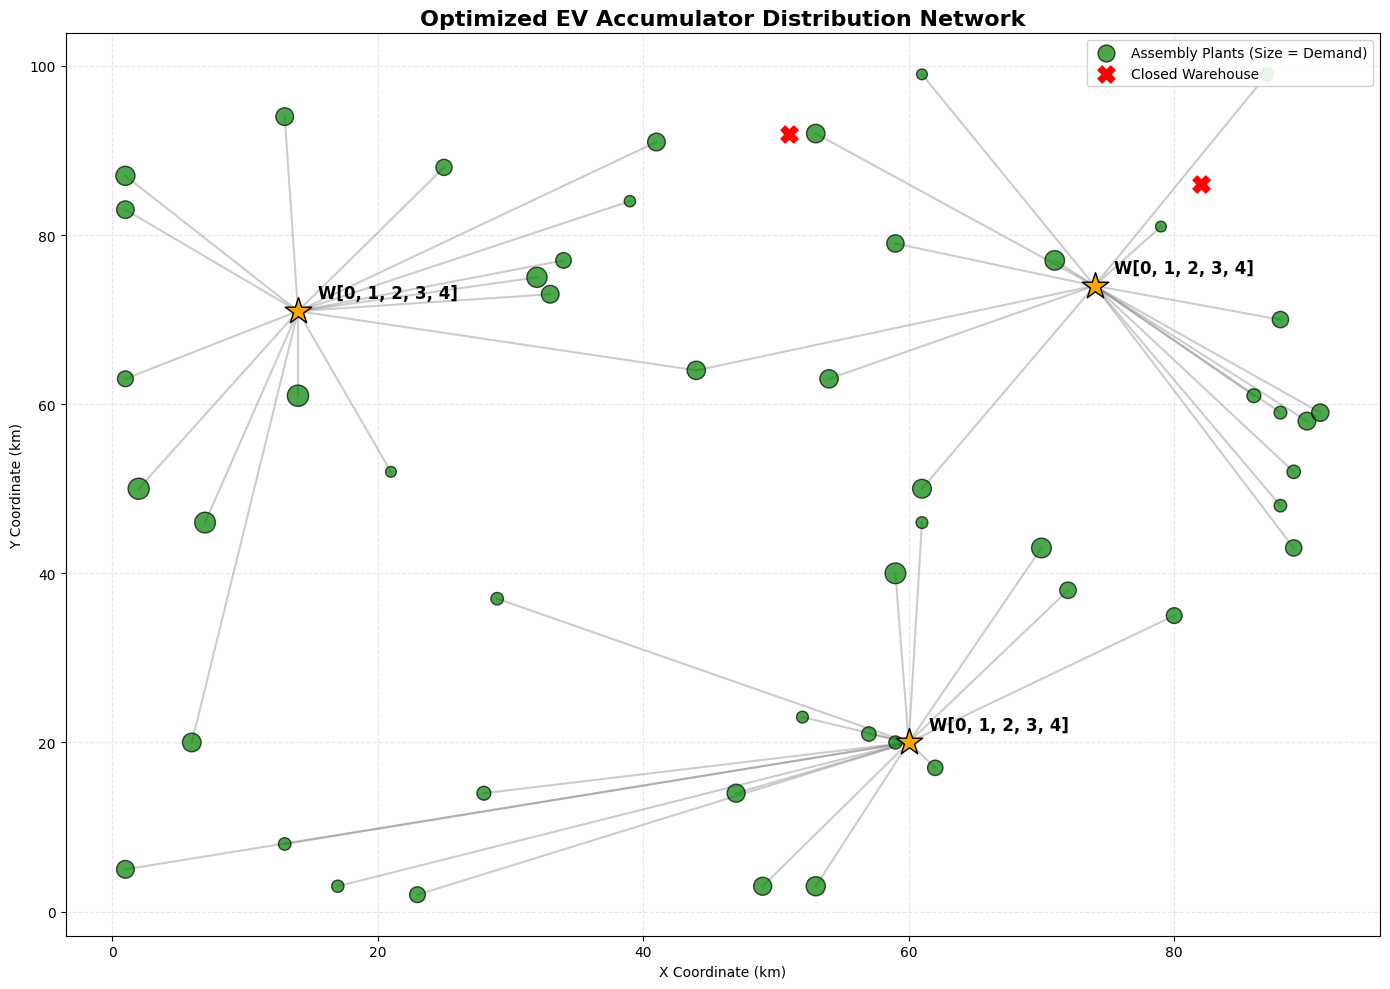

In [14]:
plt.figure(figsize=(14, 10))
plt.title("Optimized EV Accumulator Distribution Network", fontsize=16, fontweight='bold')
plt.xlabel("X Coordinate (km)")
plt.ylabel("Y Coordinate (km)")

# 1. Draw the supply routes (Active x_ij variables)
# We draw these first so the lines sit behind the location markers
for a in i:
    if y[a].varValue > 0.5: # If warehouse is OPEN
        for b in j:
            if x[a][b].varValue > 0.1: # If units are shipped on this route
                plt.plot([warehouse_coord[a][0], plant_coord[b][0]],
                         [warehouse_coord[a][1], plant_coord[b][1]],
                         c='gray', linestyle='-', linewidth=1.5, alpha=0.4)

# 2. Plot the Assembly Plants (Destinations)
# Sizing the markers based on the demand for segments
plt.scatter(plant_coord[:, 0], plant_coord[:, 1],
            c='green', edgecolor='black',
            s=[d[b] * 3 for b in j], # Scale size by demand
            label='Assembly Plants (Size = Demand)', alpha=0.7, zorder=3)

# 3. Plot the Warehouses
for a in i:
    if y[a].varValue > 0.5:
        # Open Warehouses: Green Stars
        plt.scatter(warehouse_coord[a][0], warehouse_coord[a][1],
                    c='orange', marker='*', s=400, edgecolor='black', zorder=4,
                    label='Opened Warehouse' if a == list(i)[0] else "")
        # Annotate with the warehouse ID
        plt.annotate(f"W{i}", (warehouse_coord[a][0]+1.5, warehouse_coord[a][1]+1.5),
                     fontsize=12, fontweight='bold')
    else:
        # Closed Warehouses: Red X's
        plt.scatter(warehouse_coord[a][0], warehouse_coord[a][1],
                    c='red', marker='X', s=150, zorder=4,
                    label='Closed Warehouse' if a == list(i)[0] else "")

# Clean up the legend to avoid duplicate labels
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right', framealpha=0.9)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Save the figure so you can upload it to GitHub
plt.savefig("network_optimization_result.png", dpi=300)
plt.show()